In [1]:
import pandas as pd
import glob
import os

In [2]:
file_path = "../Data/2차전처리_버스데이터.csv"

# 파일 존재 여부 먼저 확인
print(os.path.exists(file_path))

# True가 나오면 실행
df_bus = pd.read_csv(file_path, encoding="utf-8-sig")

df_bus.head(5)

True


C:\Users\cute3\AppData\Local\Temp\ipykernel_35296\2893020837.py:7: DtypeWarning: Columns (0: 정류소번호) have mixed types. Specify dtype option on import or set low_memory=False.
  df_bus = pd.read_csv(file_path, encoding="utf-8-sig")


,승하차일자,관할관청,행정동,정류소ID,정류소번호,정류소명,승차합계,초승,환승,하차
0,2023-01,성남시,성남동,205000120,6163.0,(구)성남동주민센터,103,99,4,106
1,2023-01,성남시,서현1동,206000436,7387.0,AK플라자2층,353,203,150,454
2,2023-01,성남시,삼평동,206000677,7034.0,H스퀘어.삼환하이펙스,1,1,0,25
3,2023-01,성남시,삼평동,206000678,7479.0,H스퀘어.삼환하이펙스,15,14,1,2
4,2023-01,성남시,시흥동,204000342,5333.0,I_SQUARE.창업주택,5,3,2,49


In [3]:
# 제일 많이 이용하는 곳
top10 = df_bus.groupby(['행정동', '정류소명'], as_index=False)['승차합계'].sum()

top10.sort_values('승차합계', ascending=False).head(10)

,행정동,정류소명,승차합계
705,야탑1동,야탑역.종합버스터미널(전면),12281251
706,야탑1동,야탑역.종합버스터미널(후면),10058504
266,백현동,판교역.낙생육교.현대백화점,8171270
872,이매1동,이매촌한신.서현역.AK프라자,7132904
487,서현1동,이매촌한신.서현역.AK프라자,7132904
519,성남동,모란역2.3번출구,6604519
115,금곡동,미금역.청솔마을.2001아울렛,6474268
476,서현1동,서현역.AK플라자,6296355
904,정자1동,정자역,6181445
153,금광2동,남한산성입구역.법원검찰청,4526815


## 행정동별 시계열 추이

In [4]:
dong = df_bus.groupby('행정동', as_index=False)['승차합계'].sum()
dong_top10 = dong.sort_values('승차합계', ascending=False).head(10)
dong_top10 

,행정동,승차합계
28,성남동,32416973
42,야탑1동,27329924
19,삼평동,25003445
24,서현1동,21775532
54,정자1동,16713182
5,금광1동,13513820
14,백현동,12666601
51,이매1동,12211225
20,상대원1동,11425958
2,구미1동,11198091


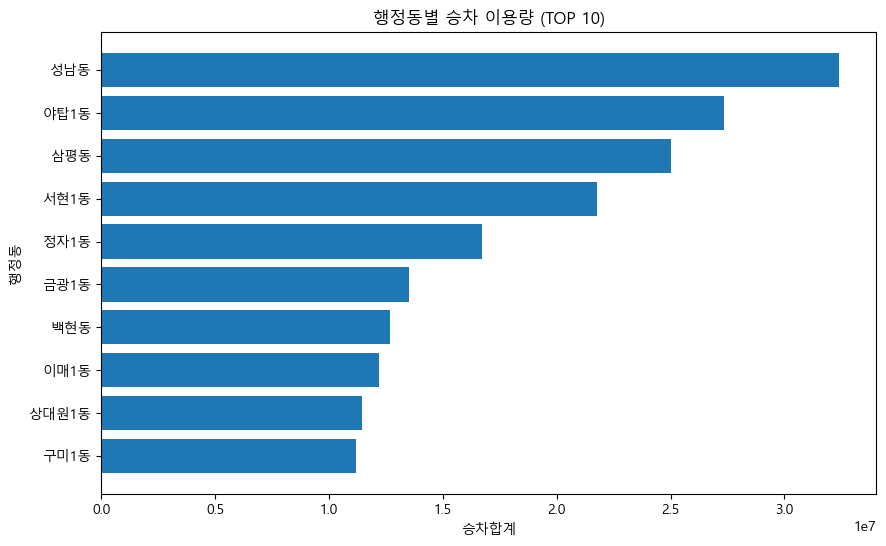

In [5]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'  # 맑은 고딕
plt.rcParams['axes.unicode_minus'] = False     # 마이너스 깨짐 방지

plt.figure(figsize=(10,6))

plt.barh(dong_top10['행정동'], dong_top10['승차합계'])

plt.xlabel('승차합계')
plt.ylabel('행정동')
plt.title('행정동별 승차 이용량 (TOP 10)')

plt.gca().invert_yaxis()

plt.show()

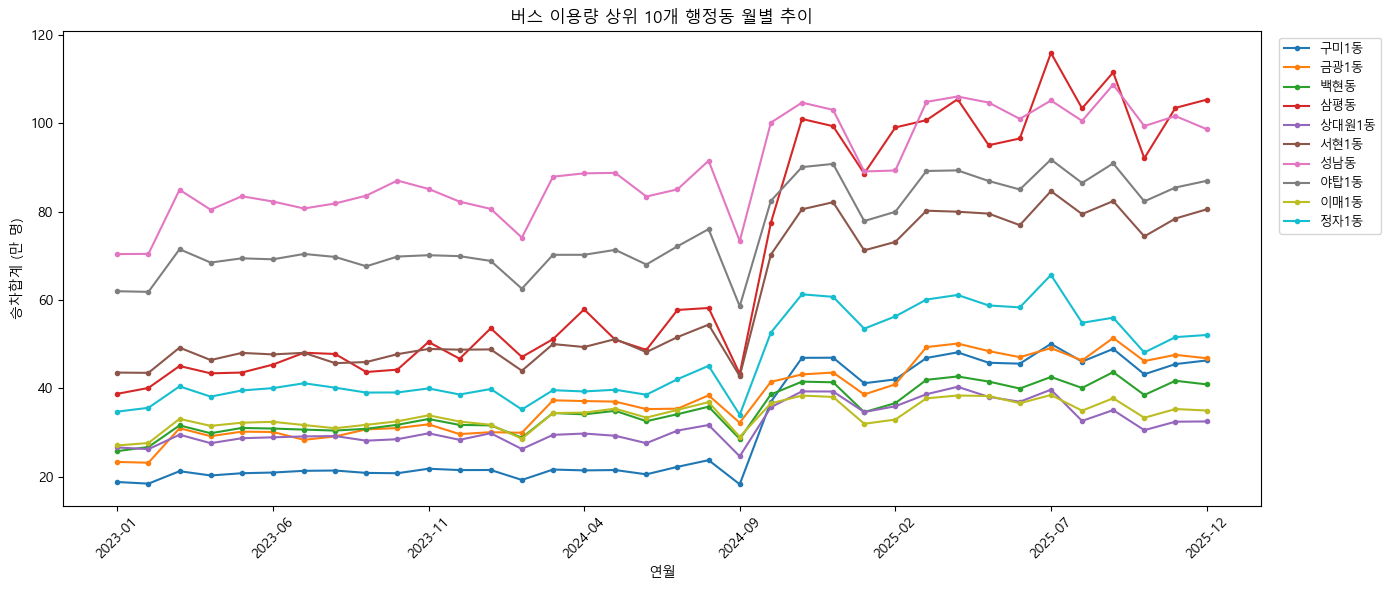

In [7]:
# 1. 월별 행정동별 승차합계
dong_m = (
    df_bus
    .groupby(['행정동', '승하차일자'])['승차합계']
    .sum()
    .reset_index()
)

# 2. 행정동별 평균 월 이용량
slope_df = (
    dong_m
    .groupby('행정동')['승차합계']
    .mean()
    .sort_values(ascending=False)
)

# 3. 이용량 상위 10개 동
top10_list = slope_df.head(10).index.tolist()

# 4. 그래프
pivot = (
    dong_m[dong_m['행정동'].isin(top10_list)]
    .pivot(index='승하차일자', columns='행정동', values='승차합계') / 1e4
)

pivot.plot(figsize=(14, 6), marker='o', ms=3)

plt.title('버스 이용량 상위 10개 행정동 월별 추이', fontsize=12)
plt.ylabel('승차합계 (만 명)')
plt.xlabel('연월')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

 - 2024년 10월 = 구조적 변화 시점 → 정책 / 노선 변경 / 외부 이벤트 가능성 높음
 -  행정동 간 격차는 계속 유지 → 상위는 계속 상위, 하위는 계속 하위
 -  전체 수요는 증가 추세 → 특히 2025년은 고점 유지 상태

In [10]:
# 1. pivot 만들기
pivot = dong_m.pivot(index='승하차일자', columns='행정동', values='승차합계')

# 2. 기울기 계산 (감소/증가 판단)
slope = pivot.apply(lambda x: x.diff().mean())

# 3. 감소 상위 10개
dec10_list = slope.nsmallest(10).index.tolist()

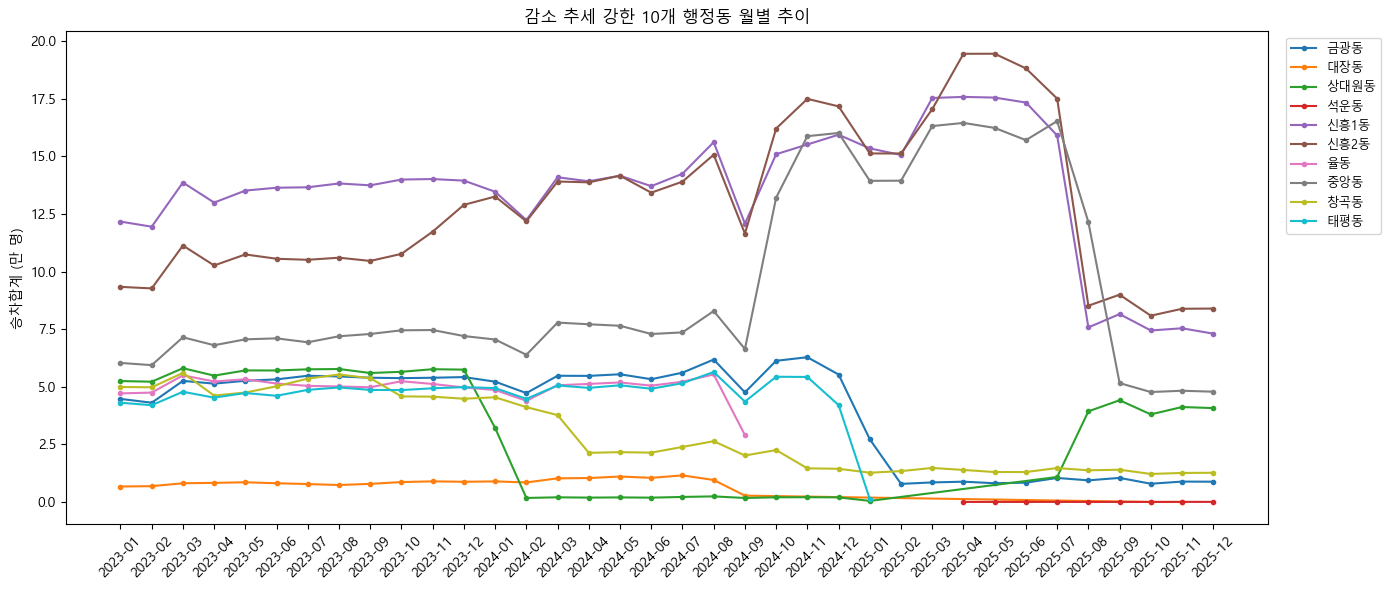

In [11]:
# 감소 추세 강한 10개 동
fig, ax = plt.subplots(figsize=(14, 6))

for dong, grp in dong_m[dong_m['행정동'].isin(dec10_list)].groupby('행정동'):
    ax.plot(grp['승하차일자'], grp['승차합계'] / 1e4,
            marker='o', ms=3, label=dong)

ax.set_title('감소 추세 강한 10개 행정동 월별 추이', fontsize=12)
ax.set_ylabel('승차합계 (만 명)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


- 2024년을 기점으로 일부 행정동에서 증가 → 감소로 전환되는 흐름이 나타남
- 감소 패턴은 다음 3가지 유형으로 구분됨

  1. 급락 후 회복 (상대원동)
  2. 급락 후 낮은 수준 유지 (신흥1동)
  3. 점진적 감소 (금광동 등)

##  최종 결론
• 전체적으로는 증가 경향이 나타나지만, 일부 지역에서는 감소 또는 정체가 동시에 발생

• 2024년이 핵심 분기점
  - 2024년 중반: 급락
  - 2024년 10월 이후: 증가 또는 감소로 분기
  → 정책 / 노선 개편 / 외부 요인의 영향 가능성 존재

• 지역 간 양극화 발생
  - 성장 지역: 삼평동, 성남동, 야탑1동 등 → 이용량 증가 + 높은 수준 유지
  - 쇠퇴 지역: 신흥1동, 금광동 등 → 감소 또는 정체

• 변화 패턴 구분
  1. 급락 후 회복
  2. 급락 후 유지
  3. 점진적 감소

In [12]:
# 1. 성남동 데이터
dong_name = '성남동'
temp = df_bus[df_bus['행정동'] == dong_name]

# 2. 정류소별 합계
stop = temp.groupby('정류소명', as_index=False)[['승차합계','하차','환승']].sum()

# 3. 기준 만들기 (상위 30%)
threshold = stop['승차합계'].quantile(0.7)

# 4. 필터링
stop_filtered = stop[stop['승차합계'] >= threshold]

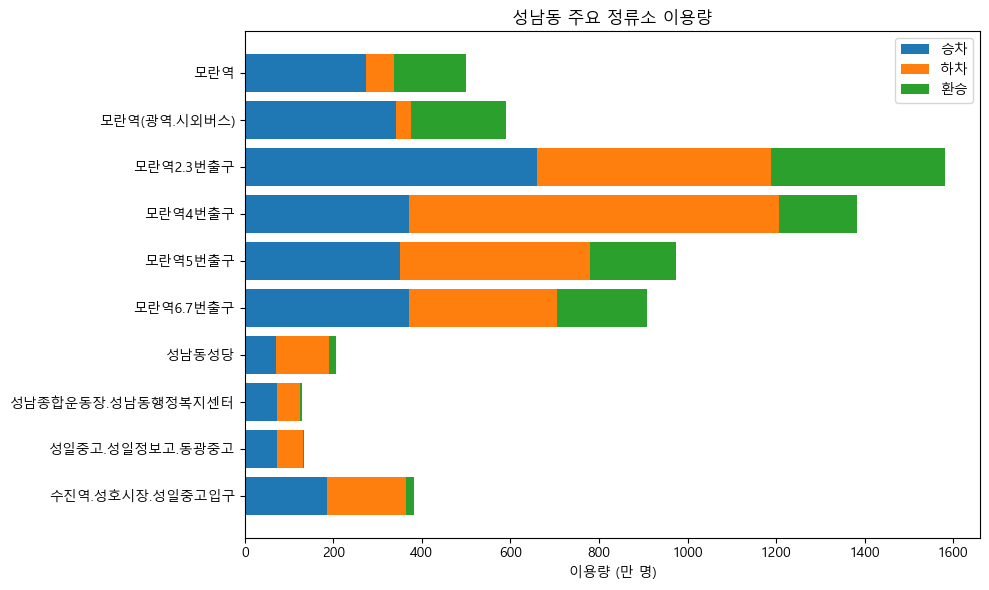

In [13]:
import matplotlib.pyplot as plt

# 단위 변환
stop_filtered['승차'] = stop_filtered['승차합계'] / 10000
stop_filtered['하차'] = stop_filtered['하차'] / 10000
stop_filtered['환승'] = stop_filtered['환승'] / 10000

plt.figure(figsize=(10,6))

plt.barh(stop_filtered['정류소명'], stop_filtered['승차'], label='승차')
plt.barh(stop_filtered['정류소명'], stop_filtered['하차'], left=stop_filtered['승차'], label='하차')
plt.barh(
    stop_filtered['정류소명'],
    stop_filtered['환승'],
    left=stop_filtered['승차'] + stop_filtered['하차'],
    label='환승'
)

plt.xlabel('이용량 (만 명)')
plt.title(f'{dong_name} 주요 정류소 이용량')
plt.legend()
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

##  초승 vs 환승 비율 — 행정동

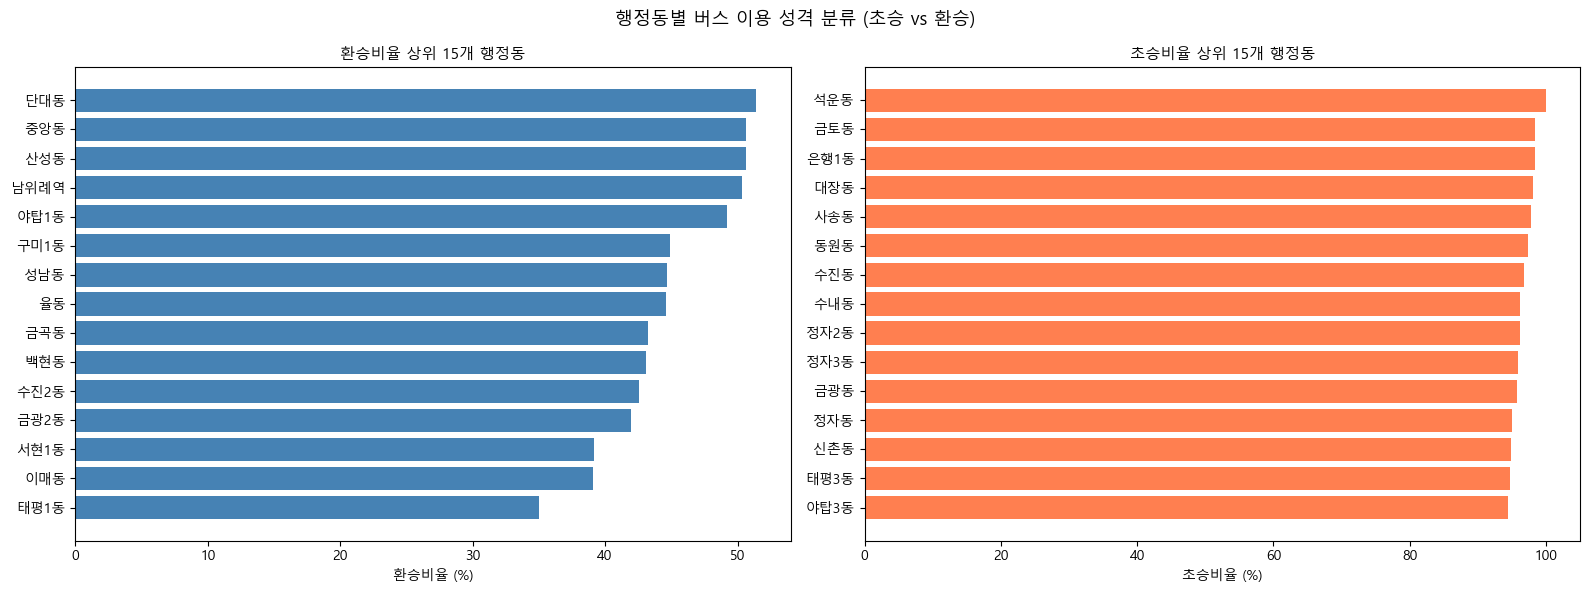

In [37]:
dong_agg = (
    df_dus
    .groupby('행정동')[['승차합계', '초승', '환승']]
    .sum()
)
dong_agg['초승비율(%)'] = dong_agg['초승'] / dong_agg['승차합계'] * 100
dong_agg['환승비율(%)'] = dong_agg['환승'] / dong_agg['승차합계'] * 100
dong_agg = dong_agg.sort_values('환승비율(%)', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_trans = dong_agg.head(15)
axes[0].barh(top_trans.index[::-1], top_trans['환승비율(%)'][::-1], color='steelblue')
axes[0].set_title('환승비율 상위 15개 행정동', fontsize=11)
axes[0].set_xlabel('환승비율 (%)')

top_orig = dong_agg.sort_values('초승비율(%)', ascending=False).head(15)
axes[1].barh(top_orig.index[::-1], top_orig['초승비율(%)'][::-1], color='coral')
axes[1].set_title('초승비율 상위 15개 행정동', fontsize=11)
axes[1].set_xlabel('초승비율 (%)')

plt.suptitle('행정동별 버스 이용 성격 분류 (초승 vs 환승)', fontsize=13)
plt.tight_layout()
plt.show()


## 행정동 × 연월 히트맵


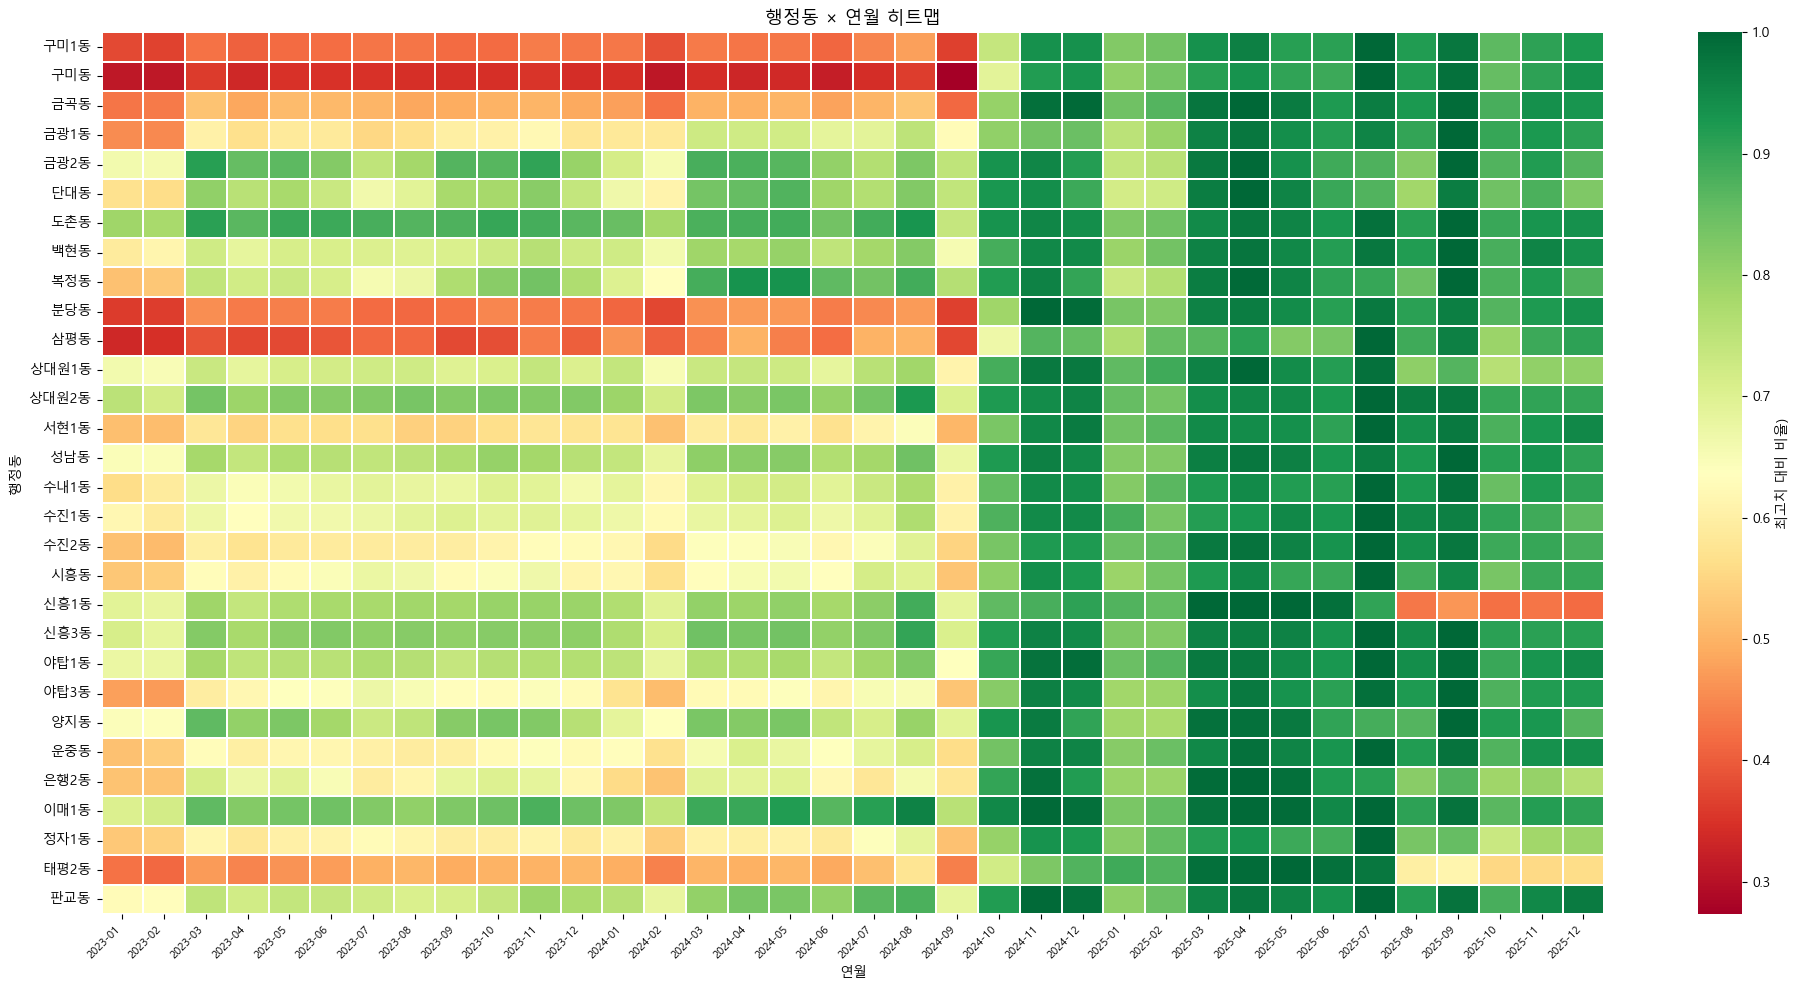

In [40]:
import seaborn as sns
top30_list = slope_df.nlargest(30, '평균월이용량').index.tolist()

pivot = (
    dong_m[dong_m['행정동'].isin(top30_list)]
    .pivot(index='행정동', columns='연월', values='승차합계')
)
pivot_norm = pivot.div(pivot.max(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(20, 10))
sns.heatmap(pivot_norm, cmap='RdYlGn', ax=ax, linewidths=0.3,
            cbar_kws={'label': '최고치 대비 비율)'})
ax.set_title('행정동 × 연월 히트맵', fontsize=13)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()


- 2023년 ~ 2024년 초반:  
  →  빨강,  노랑 구간이 많음  
  → 각 행정동 기준으로 이용량이 상대적으로 낮은 시기  

- 2024년 10월 이후:  
  →  초록 구간이 대부분  
  → 각 행정동 기준으로 이용량이 최고 수준에 근접하거나 회복된 상태